Cleared 0 old thermal-cycle image file(s).

Material Parameters
  Material                  : Aluminium 6061-T6
  Thermal Conductivity      : 167.00 W/m/K
  Density                   : 2700 kg/m³
  Specific Heat             : 896 J/kg/K
  Thermal Diffusivity       : 6.903e-05 m²/s
  Ambient Temperature       : 20.00 °C
  Melting Temperature       : 652.00 °C

Final Joint and Process Configuration
  Joint Type                : Lap joint
  Weld Arrangement          : Double fillet weld on both longitudinal edges of the overlap
  Weld Travel Direction     : +X
  Weld Length per Pass      : 200.0 mm
  Weld-Line Y Positions     : [55. 80.] mm
  Weld 1 Toe Y Position     : 51.0 mm
  Nominal Net Power         : 3168.00 W
  Nominal Travel Speed      : 8.000 mm/s
  Wire Feed Rate            : [7.0] m / min
  Monte Carlo Samples       : 100

Thermocouple Configuration
  TC1: 2.0 mm from Weld 1 toe; position = (100.0, 49.0, 4.0) mm; thermal-model distance = 2.0 mm
  TC2: 5.0 mm from Weld 1 toe; p

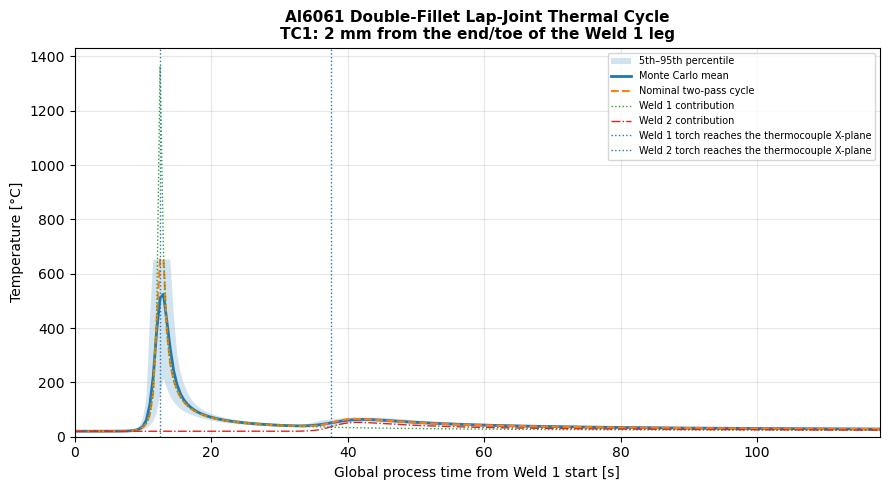

Saved thermal-cycle figure: TC_2mm_thermal_cycle.png


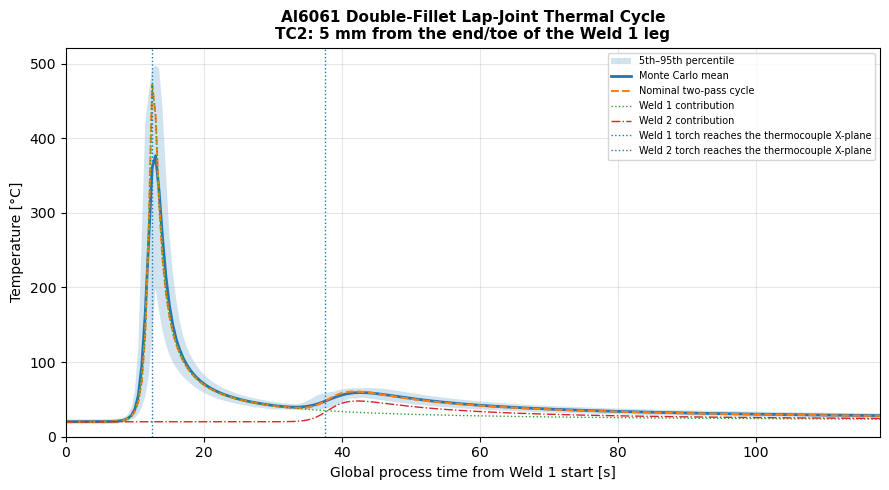

Saved thermal-cycle figure: TC_5mm_thermal_cycle.png


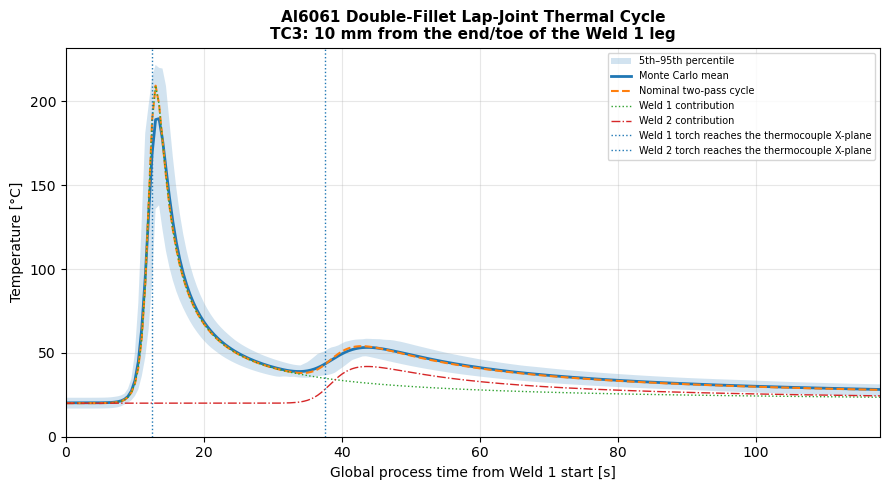

Saved thermal-cycle figure: TC_10mm_thermal_cycle.png

Thermal results written to project_core.asdf under 'thermal_results'.
  Material              : Aluminium 6061-T6
  Weld length per pass  : 200.0 mm
  Weld direction        : +X
  Weld lines            : [55. 80.] mm
  Weld 1 toe            : Y = 51.0 mm
  TC toe distances      : [ 2.  5. 10.] mm
  Thermal model uses    : [ 2.  5. 10.] mm for TC1, TC2 and TC3
  Monte Carlo samples   : 100

Tab 4 completed successfully.


In [1]:
import importlib.metadata

try:
    if importlib.metadata.version("numpy") is None:
        _original_version = importlib.metadata.version
        importlib.metadata.version = (
            lambda name: "1.26.4"
            if name.lower() == "numpy"
            else _original_version(name)
        )
except Exception:
    _original_version = importlib.metadata.version
    importlib.metadata.version = (
        lambda name: "1.26.4"
        if name.lower() == "numpy"
        else _original_version(name)
    )


from pathlib import Path
import warnings

import numpy as np
import matplotlib.pyplot as plt

from weldx import WeldxFile, Q_, GenericSeries


# ============================================================
# PROJECT FILE
# ============================================================
CORE_FILE = "project_core.asdf"

if not Path(CORE_FILE).exists():
    raise FileNotFoundError(
        f"⚠ {CORE_FILE} not found. "
        "Run corrected Tab 1, Tab 2 and corrected Tab 3 first!"
    )


# ============================================================
# CLEANUP OLD OUTPUT IMAGES
# ============================================================
old_images = [
    "TC_2mm_thermal_cycle.png",
    "TC_5mm_thermal_cycle.png",
    "TC_10mm_thermal_cycle.png",
    "TC_15mm_thermal_cycle.png",
]

removed = 0

for image_name in old_images:
    image_path = Path(image_name)

    if image_path.exists():
        image_path.unlink()
        removed += 1

plt.close("all")

print(
    f"Cleared {removed} old thermal-cycle image file(s)."
)


# ============================================================
# LOAD THE SHARED WELDX MODEL
# ============================================================
with WeldxFile(CORE_FILE, mode="r") as wx:
    core = wx.copy()


required_keys = [
    "material",
    "geometry",
    "process",
    "gmaw_process",
    "monte_carlo",
]

missing_keys = [
    key
    for key in required_keys
    if key not in core
]

if missing_keys:
    raise KeyError(
        f"Missing required data in {CORE_FILE}: {missing_keys}. "
        "Run the preceding corrected tabs in order."
    )


material_core = core["material"]
geometry_core = core["geometry"]
process_core = core["process"]
mc_core = core["monte_carlo"]


# ============================================================
# ALUMINIUM 6061-T6 MATERIAL PROPERTIES
# ============================================================
material_name = str(
    material_core["common_name"]
)

k_W_m_K = float(
    material_core["thermal_conductivity"]
    .to("W/m/K")
    .m
)

rho_kg_m3 = float(
    material_core["density"]
    .to("kg/m^3")
    .m
)

cp_J_kg_K = float(
    material_core["specific_heat"]
    .to("J/kg/K")
    .m
)

T0_K = float(
    material_core["ambient_temperature"]
    .to("K")
    .m
)

T_melting_K = float(
    material_core["melting_point"]
    .to("K")
    .m
)

alpha_m2_s = (
    k_W_m_K
    / (
        rho_kg_m3
        * cp_J_kg_K
    )
)


# ============================================================
# FINAL LAP-JOINT GEOMETRY
# ============================================================
# Coordinate system:
#   X = 200 mm plate length and weld-travel direction
#   Y = plate-width direction
#   Z = plate-thickness direction
#
# Lower plate:
#   X = 0 ... 200 mm
#   Y = 0 ... 80 mm
#   Z = 0 ... 4 mm
#
# Upper plate:
#   X = 0 ... 200 mm
#   Y = 55 ... 135 mm
#   Z = 4 ... 8 mm
#
# Weld 1:
#   Y = 55 mm
#   4 mm horizontal leg extends toward decreasing Y.
#   Weld toe/end is therefore at Y = 51 mm.
#
# Weld 2:
#   Y = 80 mm
#   4 mm horizontal leg extends toward increasing Y.
#
# Both welds travel along X from 0 to 200 mm.

joint_type = str(
    geometry_core["joint_type"]
)

joint_configuration = str(
    geometry_core["joint_configuration"]
)

plate_length_m = float(
    geometry_core["plate_length"]
    .to("m")
    .m
)

plate_width_m = float(
    geometry_core["plate_width"]
    .to("m")
    .m
)

plate_thickness_m = float(
    geometry_core["plate_thickness"]
    .to("m")
    .m
)

overlap_m = float(
    geometry_core["overlap"]
    .to("m")
    .m
)

fillet_leg_m = float(
    geometry_core["fillet_leg"]
    .to("m")
    .m
)

weld_length_m = float(
    geometry_core["weld_length"]
    .to("m")
    .m
)

weld_line_y_m = np.asarray(
    geometry_core["weld_line_y_positions"]
    .to("m")
    .m,
    dtype=float,
)

sensor_labels = [
    str(label)
    for label in geometry_core["sensor_labels"]
]

sensor_toe_distances_m = np.asarray(
    geometry_core["thermo_distance"]
    .to("m")
    .m,
    dtype=float,
)

sensor_x_m = np.asarray(
    geometry_core["thermocouple_x_positions"]
    .to("m")
    .m,
    dtype=float,
)

sensor_y_m = np.asarray(
    geometry_core["thermocouple_y_positions"]
    .to("m")
    .m,
    dtype=float,
)

sensor_z_m = np.asarray(
    geometry_core["thermocouple_z_positions"]
    .to("m")
    .m,
    dtype=float,
)


# ============================================================
# GEOMETRY VALIDATION
# ============================================================
expected_scalars = {
    "plate length": (
        plate_length_m,
        0.200,
    ),
    "plate width": (
        plate_width_m,
        0.080,
    ),
    "plate thickness": (
        plate_thickness_m,
        0.004,
    ),
    "overlap": (
        overlap_m,
        0.025,
    ),
    "fillet leg": (
        fillet_leg_m,
        0.004,
    ),
    "weld length": (
        weld_length_m,
        0.200,
    ),
}

for name, (
    actual_value,
    expected_value,
) in expected_scalars.items():
    if not np.isclose(
        actual_value,
        expected_value,
        rtol=0.0,
        atol=1.0e-12,
    ):
        raise ValueError(
            f"Unexpected {name}: "
            f"{actual_value * 1000.0:.3f} mm. "
            f"Expected {expected_value * 1000.0:.3f} mm."
        )


if geometry_core["weld_travel_direction"] != "+x":
    raise ValueError(
        "Tab 4 requires the weld-travel direction to be +x."
    )


if not np.allclose(
    weld_line_y_m,
    np.array(
        [
            0.055,
            0.080,
        ]
    ),
    rtol=0.0,
    atol=1.0e-12,
):
    raise ValueError(
        "Weld lines must be located at "
        "Y = 55 mm and Y = 80 mm."
    )


if not np.allclose(
    sensor_toe_distances_m,
    np.array(
        [
            0.002,
            0.005,
            0.010,
        ]
    ),
    rtol=0.0,
    atol=1.0e-12,
):
    raise ValueError(
        "Thermocouple distances from the weld toe must be "
        "2 mm, 5 mm and 10 mm."
    )


if not (
    len(sensor_labels)
    == len(sensor_toe_distances_m)
    == len(sensor_x_m)
    == len(sensor_y_m)
    == len(sensor_z_m)
    == 3
):
    raise ValueError(
        "Tab 4 requires three thermocouple labels, "
        "distances and coordinate sets."
    )


# ============================================================
# WELD-TOE AND ACTUAL SOURCE DISTANCES
# ============================================================
weld_1_y_m = float(
    weld_line_y_m[0]
)

weld_2_y_m = float(
    weld_line_y_m[1]
)

weld_1_toe_y_m = (
    weld_1_y_m
    - fillet_leg_m
)

calculated_toe_distances_m = (
    weld_1_toe_y_m
    - sensor_y_m
)

if not np.allclose(
    calculated_toe_distances_m,
    sensor_toe_distances_m,
    rtol=0.0,
    atol=1.0e-12,
):
    raise ValueError(
        "The thermocouple coordinates do not match distances "
        "measured from the end/toe of the Weld 1 leg."
    )


# Exact transverse distances used by the thermal model.
#
# For Weld 1, the requested thermocouple reference is the outer
# end/toe of its 4 mm horizontal leg. Therefore, the model uses:
#     TC1 = 2 mm
#     TC2 = 5 mm
#     TC3 = 10 mm
#
# Weld 2 remains a secondary heat source. Its distance is based
# on the physical thermocouple coordinates and Weld 2 centreline.
distance_to_weld_1_model_m = np.asarray(
    sensor_toe_distances_m,
    dtype=float,
)

distance_to_weld_2_model_m = np.abs(
    sensor_y_m
    - weld_2_y_m
)

distance_to_each_weld_model_m = np.column_stack(
    [
        distance_to_weld_1_model_m,
        distance_to_weld_2_model_m,
    ]
)

if not np.allclose(
    distance_to_weld_1_model_m,
    np.array(
        [
            0.002,
            0.005,
            0.010,
        ]
    ),
    rtol=0.0,
    atol=1.0e-12,
):
    raise ValueError(
        "The Weld 1 thermal-model distances must be exactly "
        "2 mm, 5 mm and 10 mm."
    )


# ============================================================
# MONTE CARLO DATA FROM TAB 2
# ============================================================
N = int(
    mc_core["n_samples"]
)

mc_net_power_W = np.asarray(
    mc_core["net_power"]
    .to("W")
    .m,
    dtype=float,
)

mc_speed_m_s = np.asarray(
    mc_core["speed"]
    .to("m/s")
    .m,
    dtype=float,
)

mc_sensor_noise_degC = np.asarray(
    mc_core["sensor_noise"]
    .to("delta_degC")
    .m,
    dtype=float,
)


if not (
    len(mc_net_power_W)
    == len(mc_speed_m_s)
    == len(mc_sensor_noise_degC)
    == N
):
    raise ValueError(
        "Monte Carlo arrays do not match n_samples. "
        "Re-run Tab 2 after corrected Tab 1."
    )


# ============================================================
# NOMINAL GMAW VALUES
# ============================================================
Q_nom_W = float(
    process_core["net_power"]
    .to("W")
    .m
)

v_nom_m_s = float(
    process_core["speed"]
    .to("m/s")
    .m
)

wire_feed_nom = (
    core["gmaw_process"]
    .parameters["wire_feedrate"]
    .data
)


# ============================================================
# MODEL SUMMARY
# ============================================================
print("\nMaterial Parameters")

print(
    f"  Material                  : {material_name}"
)

print(
    f"  Thermal Conductivity      : "
    f"{k_W_m_K:.2f} W/m/K"
)

print(
    f"  Density                   : "
    f"{rho_kg_m3:.0f} kg/m³"
)

print(
    f"  Specific Heat             : "
    f"{cp_J_kg_K:.0f} J/kg/K"
)

print(
    f"  Thermal Diffusivity       : "
    f"{alpha_m2_s:.3e} m²/s"
)

print(
    f"  Ambient Temperature       : "
    f"{T0_K - 273.15:.2f} °C"
)

print(
    f"  Melting Temperature       : "
    f"{T_melting_K - 273.15:.2f} °C"
)


print("\nFinal Joint and Process Configuration")

print(
    f"  Joint Type                : {joint_type}"
)

print(
    f"  Weld Arrangement          : {joint_configuration}"
)

print(
    f"  Weld Travel Direction     : +X"
)

print(
    f"  Weld Length per Pass      : "
    f"{weld_length_m * 1000.0:.1f} mm"
)

print(
    f"  Weld-Line Y Positions     : "
    f"{weld_line_y_m * 1000.0} mm"
)

print(
    f"  Weld 1 Toe Y Position     : "
    f"{weld_1_toe_y_m * 1000.0:.1f} mm"
)

print(
    f"  Nominal Net Power         : "
    f"{Q_nom_W:.2f} W"
)

print(
    f"  Nominal Travel Speed      : "
    f"{v_nom_m_s * 1000.0:.3f} mm/s"
)

print(
    f"  Wire Feed Rate            : {wire_feed_nom}"
)

print(
    f"  Monte Carlo Samples       : {N}"
)


print("\nThermocouple Configuration")

for index, label in enumerate(
    sensor_labels
):
    print(
        f"  {label}: "
        f"{sensor_toe_distances_m[index] * 1000.0:.1f} mm "
        f"from Weld 1 toe; "
        f"position = "
        f"({sensor_x_m[index] * 1000.0:.1f}, "
        f"{sensor_y_m[index] * 1000.0:.1f}, "
        f"{sensor_z_m[index] * 1000.0:.1f}) mm; "
        f"thermal-model distance = "
        f"{distance_to_weld_1_model_m[index] * 1000.0:.1f} mm"
    )


# ============================================================
# ROSENTHAL 3D MOVING-HEAT-SOURCE MODEL
# ============================================================
def rosenthal_3d_temperature_rise(
    Q_W,
    v_m_s,
    k_W_m_K,
    alpha_m2_s,
    longitudinal_m,
    transverse_m,
    depth_m,
    R_min_m=0.5e-3,
):
    """
    Return the temperature rise above ambient for a 3D
    Rosenthal moving point heat source.

    longitudinal_m:
        Sensor X coordinate minus current torch X coordinate.

    transverse_m:
        Normal Y distance between sensor and weld centreline.

    depth_m:
        Z distance between sensor and heat-source plane.
    """

    R_m = np.sqrt(
        longitudinal_m**2
        + transverse_m**2
        + depth_m**2
    )

    R_m = np.maximum(
        R_m,
        R_min_m,
    )

    exponent = (
        -v_m_s
        * (
            longitudinal_m
            + R_m
        )
        / (
            2.0
            * alpha_m2_s
        )
    )

    exponent = np.clip(
        exponent,
        -700.0,
        0.0,
    )

    delta_T_K = (
        Q_W
        / (
            2.0
            * np.pi
            * k_W_m_K
            * R_m
        )
    ) * np.exp(
        exponent
    )

    return delta_T_K


def double_fillet_lap_joint_cycle(
    Q_W,
    v_m_s,
    time_s,
    sensor_x,
    sensor_y,
    sensor_z,
    weld_1_toe_distance,
    return_components=False,
):
    """
    Calculate a sequential two-pass thermal cycle.

    Pass 1:
        Weld 1 travels along +X from X = 0 to 200 mm,
        at Y = 55 mm.

    Pass 2:
        Weld 2 starts after Pass 1 and travels along +X
        from X = 0 to 200 mm, at Y = 80 mm.

    The two Rosenthal temperature rises are superimposed.
    """

    pass_duration_s = (
        weld_length_m
        / v_m_s
    )

    pass_start_times_s = np.array(
        [
            0.0,
            pass_duration_s,
        ],
        dtype=float,
    )

    total_temperature_rise_K = np.zeros_like(
        time_s,
        dtype=float,
    )

    source_temperature_rises_K = []

    for weld_index, (
        weld_y,
        pass_start_s,
    ) in enumerate(
        zip(
            weld_line_y_m,
            pass_start_times_s,
        )
    ):
        local_time_s = (
            time_s
            - pass_start_s
        )

        source_x_m = (
            v_m_s
            * local_time_s
        )

        longitudinal_m = (
            sensor_x
            - source_x_m
        )

        if weld_index == 0:
            # Weld 1 is referenced from the outer end/toe of
            # its horizontal leg. This is exactly 2, 5 or 10 mm.
            transverse_m = float(
                weld_1_toe_distance
            )

        else:
            # Weld 2 remains physically separated from the
            # thermocouples and uses its actual Y distance.
            transverse_m = abs(
                sensor_y
                - weld_y
            )

        source_z_m = (
            plate_thickness_m
        )

        depth_m = abs(
            sensor_z
            - source_z_m
        )

        delta_T_K = rosenthal_3d_temperature_rise(
            Q_W=Q_W,
            v_m_s=v_m_s,
            k_W_m_K=k_W_m_K,
            alpha_m2_s=alpha_m2_s,
            longitudinal_m=longitudinal_m,
            transverse_m=transverse_m,
            depth_m=depth_m,
        )

        # A pass contributes only after its start time.
        delta_T_K = np.where(
            local_time_s >= 0.0,
            delta_T_K,
            0.0,
        )

        total_temperature_rise_K += (
            delta_T_K
        )

        source_temperature_rises_K.append(
            delta_T_K
        )

    temperature_K = (
        T0_K
        + total_temperature_rise_K
    )

    temperature_K = np.minimum(
        temperature_K,
        T_melting_K,
    )

    temperature_degC = (
        temperature_K
        - 273.15
    )

    if return_components:
        component_temperatures_degC = [
            (
                T0_K
                + component
                - 273.15
            )
            for component
            in source_temperature_rises_K
        ]

        return (
            temperature_degC,
            component_temperatures_degC,
            pass_duration_s,
        )

    return temperature_degC


# ============================================================
# TIME CONFIGURATION
# ============================================================
DT_S = 0.5
COOLING_WINDOW_S = 60.0

slowest_speed_m_s = float(
    np.min(
        mc_speed_m_s
    )
)

maximum_two_pass_duration_s = (
    2.0
    * weld_length_m
    / slowest_speed_m_s
)

t_start_s = 0.0

t_end_s = float(
    np.ceil(
        maximum_two_pass_duration_s
        + COOLING_WINDOW_S
    )
)

t_array_s = np.arange(
    t_start_s,
    t_end_s + DT_S,
    DT_S,
)

nominal_pass_duration_s = (
    weld_length_m
    / v_nom_m_s
)

nominal_total_weld_duration_s = (
    2.0
    * nominal_pass_duration_s
)


print("\nTime Configuration")

print(
    f"  Time Start                : "
    f"{t_start_s:.1f} s"
)

print(
    f"  Time End                  : "
    f"{t_end_s:.1f} s"
)

print(
    f"  Time Step                 : "
    f"{DT_S:.1f} s"
)

print(
    f"  Number of Time Steps      : "
    f"{len(t_array_s)}"
)

print(
    f"  Nominal Duration per Pass : "
    f"{nominal_pass_duration_s:.3f} s"
)

print(
    f"  Nominal Two-Pass Duration : "
    f"{nominal_total_weld_duration_s:.3f} s"
)


# ============================================================
# MONTE CARLO THERMAL SIMULATION
# ============================================================
warnings.filterwarnings(
    "ignore"
)

thermal_results = {}
peak_temperatures = {}
peak_times = {}


print("\nThermal Simulation")

print(
    f"  Samples                   : {N}"
)

print(
    f"  Thermocouples             : "
    f"{len(sensor_labels)}"
)

print(
    f"  Weld Passes               : 2"
)


for sensor_index, label in enumerate(
    sensor_labels
):
    T_mc_degC = np.zeros(
        (
            N,
            len(t_array_s),
        ),
        dtype=float,
    )

    for sample_index in range(
        N
    ):
        T_sample_degC = (
            double_fillet_lap_joint_cycle(
                Q_W=mc_net_power_W[
                    sample_index
                ],
                v_m_s=mc_speed_m_s[
                    sample_index
                ],
                time_s=t_array_s,
                sensor_x=sensor_x_m[
                    sensor_index
                ],
                sensor_y=sensor_y_m[
                    sensor_index
                ],
                sensor_z=sensor_z_m[
                    sensor_index
                ],
                weld_1_toe_distance=(
                    sensor_toe_distances_m[
                        sensor_index
                    ]
                ),
            )
        )

        T_sample_degC = (
            T_sample_degC
            + mc_sensor_noise_degC[
                sample_index
            ]
        )

        T_sample_degC = np.minimum(
            T_sample_degC,
            T_melting_K - 273.15,
        )

        T_mc_degC[
            sample_index,
            :,
        ] = T_sample_degC

    thermal_results[
        label
    ] = T_mc_degC

    peak_temperatures[
        label
    ] = T_mc_degC.max(
        axis=1
    )

    sample_peak_indices = np.argmax(
        T_mc_degC,
        axis=1,
    )

    peak_times[
        label
    ] = t_array_s[
        sample_peak_indices
    ]

    print(
        f"  {label}: "
        f"mean peak = "
        f"{peak_temperatures[label].mean():.1f} °C, "
        f"standard deviation = "
        f"{peak_temperatures[label].std():.1f} °C, "
        f"mean peak time = "
        f"{peak_times[label].mean():.2f} s"
    )


# ============================================================
# NOMINAL TWO-PASS CYCLES
# ============================================================
nominal_cycles = {}
nominal_weld_1_components = {}
nominal_weld_2_components = {}


for sensor_index, label in enumerate(
    sensor_labels
):
    (
        nominal_total_degC,
        nominal_components_degC,
        _,
    ) = double_fillet_lap_joint_cycle(
        Q_W=Q_nom_W,
        v_m_s=v_nom_m_s,
        time_s=t_array_s,
        sensor_x=sensor_x_m[
            sensor_index
        ],
        sensor_y=sensor_y_m[
            sensor_index
        ],
        sensor_z=sensor_z_m[
            sensor_index
        ],
        weld_1_toe_distance=(
            sensor_toe_distances_m[
                sensor_index
            ]
        ),
        return_components=True,
    )

    nominal_cycles[
        label
    ] = nominal_total_degC

    nominal_weld_1_components[
        label
    ] = nominal_components_degC[
        0
    ]

    nominal_weld_2_components[
        label
    ] = nominal_components_degC[
        1
    ]


print("\nNominal Thermal Cycles")

for label in sensor_labels:
    peak_index = int(
        np.argmax(
            nominal_cycles[
                label
            ]
        )
    )

    print(
        f"  {label}: "
        f"peak = "
        f"{nominal_cycles[label][peak_index]:.1f} °C "
        f"at t = "
        f"{t_array_s[peak_index]:.2f} s"
    )


# ============================================================
# STORE THE SINGLE-SOURCE ROSENTHAL EQUATION
# ============================================================
rosenthal_expression = (
    "T0 + "
    "(Qnet/(2*pi*k*sqrt(x**2+y**2+z**2))) "
    "* exp("
    "-v*(x+sqrt(x**2+y**2+z**2))"
    "/(2*alpha)"
    ")"
)

rosenthal_model = GenericSeries(
    rosenthal_expression,
    parameters={
        "Qnet": Q_(
            Q_nom_W,
            "W",
        ),
        "k": Q_(
            k_W_m_K,
            "W/m/K",
        ),
        "v": Q_(
            v_nom_m_s,
            "m/s",
        ),
        "alpha": Q_(
            alpha_m2_s,
            "m^2/s",
        ),
        "T0": Q_(
            T0_K,
            "K",
        ),
    },
    units={
        "x": "m",
        "y": "m",
        "z": "m",
    },
)


# ============================================================
# THERMAL-CYCLE PLOTS
# ============================================================
output_files = [
    "TC_2mm_thermal_cycle.png",
    "TC_5mm_thermal_cycle.png",
    "TC_10mm_thermal_cycle.png",
]


def plot_thermal_cycle(
    sensor_index,
    label,
    output_file,
):
    T_mc_degC = thermal_results[
        label
    ]

    T_nominal_degC = nominal_cycles[
        label
    ]

    T_mean_degC = T_mc_degC.mean(
        axis=0
    )

    T_p5_degC = np.percentile(
        T_mc_degC,
        5,
        axis=0,
    )

    T_p95_degC = np.percentile(
        T_mc_degC,
        95,
        axis=0,
    )

    # The sensor is at X = 100 mm, so these are the
    # times at which each torch reaches the TC plane.
    pass_1_crossing_s = (
        sensor_x_m[
            sensor_index
        ]
        / v_nom_m_s
    )

    pass_2_crossing_s = (
        nominal_pass_duration_s
        + sensor_x_m[
            sensor_index
        ]
        / v_nom_m_s
    )

    fig, ax = plt.subplots(
        figsize=(
            9,
            5,
        )
    )

    ax.fill_between(
        t_array_s,
        T_p5_degC,
        T_p95_degC,
        alpha=0.20,
        label="5th–95th percentile",
    )

    ax.plot(
        t_array_s,
        T_mean_degC,
        linewidth=2.0,
        label="Monte Carlo mean",
    )

    ax.plot(
        t_array_s,
        T_nominal_degC,
        linewidth=1.5,
        linestyle="--",
        label="Nominal two-pass cycle",
    )

    ax.plot(
        t_array_s,
        nominal_weld_1_components[
            label
        ],
        linewidth=1.0,
        linestyle=":",
        label="Weld 1 contribution",
    )

    ax.plot(
        t_array_s,
        nominal_weld_2_components[
            label
        ],
        linewidth=1.0,
        linestyle="-.",
        label="Weld 2 contribution",
    )

    ax.axvline(
        pass_1_crossing_s,
        linestyle=":",
        linewidth=1.0,
        label=(
            "Weld 1 torch reaches "
            "the thermocouple X-plane"
        ),
    )

    ax.axvline(
        pass_2_crossing_s,
        linestyle=":",
        linewidth=1.0,
        label=(
            "Weld 2 torch reaches "
            "the thermocouple X-plane"
        ),
    )

    ax.set_title(
        (
            "Al6061 Double-Fillet Lap-Joint "
            "Thermal Cycle\n"
            f"{label}: "
            f"{sensor_toe_distances_m[sensor_index] * 1000.0:.0f} mm "
            "from the end/toe of the Weld 1 leg"
        ),
        fontsize=11,
        fontweight="bold",
    )

    ax.set_xlabel(
        "Global process time from Weld 1 start [s]"
    )

    ax.set_ylabel(
        "Temperature [°C]"
    )

    ax.set_xlim(
        t_start_s,
        t_end_s,
    )

    ax.set_ylim(
        bottom=0.0,
    )

    ax.grid(
        True,
        alpha=0.30,
    )

    ax.legend(
        fontsize=7,
        loc="best",
    )

    plt.tight_layout()

    plt.savefig(
        output_file,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Saved thermal-cycle figure: "
        f"{output_file}"
    )


for sensor_index, (
    label,
    output_file,
) in enumerate(
    zip(
        sensor_labels,
        output_files,
    )
):
    plot_thermal_cycle(
        sensor_index=sensor_index,
        label=label,
        output_file=output_file,
    )


# ============================================================
# STORE RESULTS IN PROJECT_CORE.ASDF
# ============================================================
thermal_results_asdf = {
    "n_samples": N,

    "data_source": (
        "Computed using a 3D Rosenthal moving-heat-source "
        "model with Monte Carlo uncertainty propagation. "
        "Two sequential 200 mm fillet welds travel along +X. "
        "Thermocouple distances are measured from the outer "
        "end/toe of the Weld 1 horizontal leg."
    ),

    "material_name": (
        material_name
    ),

    "joint_type": (
        joint_type
    ),

    "joint_configuration": (
        joint_configuration
    ),

    "weld_count": 2,

    "weld_travel_direction": (
        "+x"
    ),

    "weld_sequence": [
        (
            "Weld 1: Y = 55 mm, "
            "200 mm travel along +X"
        ),
        (
            "Weld 2: Y = 80 mm, "
            "200 mm travel along +X"
        ),
    ],

    "weld_line_y_positions": Q_(
        weld_line_y_m,
        "m",
    ),

    "weld_length": Q_(
        weld_length_m,
        "m",
    ),

    "weld_1_toe_y": Q_(
        weld_1_toe_y_m,
        "m",
    ),

    "nominal_pass_duration": Q_(
        nominal_pass_duration_s,
        "s",
    ),

    "nominal_total_weld_duration": Q_(
        nominal_total_weld_duration_s,
        "s",
    ),

    "time_step": Q_(
        DT_S,
        "s",
    ),

    "cooling_window": Q_(
        COOLING_WINDOW_S,
        "s",
    ),

    "t_array": Q_(
        t_array_s,
        "s",
    ),

    "sensor_labels": (
        sensor_labels
    ),

    "sensor_reference": (
        "Outer end/toe of the Weld 1 "
        "4 mm horizontal leg"
    ),

    "sensor_distances": Q_(
        sensor_toe_distances_m,
        "m",
    ),

    "sensor_distances_mm": Q_(
        sensor_toe_distances_m
        * 1000.0,
        "mm",
    ),

    "sensor_x_positions": Q_(
        sensor_x_m,
        "m",
    ),

    "sensor_y_positions": Q_(
        sensor_y_m,
        "m",
    ),

    "sensor_z_positions": Q_(
        sensor_z_m,
        "m",
    ),

    "sensor_distances_used_by_thermal_model": Q_(
        distance_to_each_weld_model_m,
        "m",
    ),

    "weld_1_model_distance_reference": (
        "Outer end/toe of the Weld 1 horizontal fillet-weld leg"
    ),

    "weld_1_model_distances_mm": Q_(
        distance_to_weld_1_model_m
        * 1000.0,
        "mm",
    ),

    "weld_2_model_distance_reference": (
        "Physical distance from each thermocouple to the "
        "Weld 2 centreline"
    ),

    "thermal_results": {
        label: Q_(
            thermal_results[
                label
            ],
            "degC",
        )
        for label
        in sensor_labels
    },

    "peak_temperatures": {
        label: Q_(
            peak_temperatures[
                label
            ],
            "degC",
        )
        for label
        in sensor_labels
    },

    "peak_times": {
        label: Q_(
            peak_times[
                label
            ],
            "s",
        )
        for label
        in sensor_labels
    },

    "nominal_cycles": {
        label: Q_(
            nominal_cycles[
                label
            ],
            "degC",
        )
        for label
        in sensor_labels
    },

    "nominal_weld_1_components": {
        label: Q_(
            nominal_weld_1_components[
                label
            ],
            "degC",
        )
        for label
        in sensor_labels
    },

    "nominal_weld_2_components": {
        label: Q_(
            nominal_weld_2_components[
                label
            ],
            "degC",
        )
        for label
        in sensor_labels
    },

    "material": {
        "thermal_conductivity": Q_(
            k_W_m_K,
            "W/m/K",
        ),
        "density": Q_(
            rho_kg_m3,
            "kg/m^3",
        ),
        "specific_heat": Q_(
            cp_J_kg_K,
            "J/kg/K",
        ),
        "thermal_diffusivity": Q_(
            alpha_m2_s,
            "m^2/s",
        ),
        "ambient_temperature": Q_(
            T0_K,
            "K",
        ),
        "melting_point": Q_(
            T_melting_K,
            "K",
        ),
    },

    "process": {
        "net_power_nominal": Q_(
            Q_nom_W,
            "W",
        ),
        "speed_nominal": Q_(
            v_nom_m_s,
            "m/s",
        ),
        "wire_feedrate_nominal": (
            wire_feed_nom
        ),
    },

    "rosenthal_model_expr": (
        rosenthal_model
    ),

    "source_superposition": {
        "method": (
            "Linear superposition of the temperature "
            "rises from two sequential Rosenthal "
            "moving heat sources."
        ),
        "pass_1_start": Q_(
            0.0,
            "s",
        ),
        "pass_2_start_nominal": Q_(
            nominal_pass_duration_s,
            "s",
        ),
        "temperature_cap": Q_(
            T_melting_K,
            "K",
        ),
    },

    "output_images": {
        sensor_labels[index]: (
            output_files[
                index
            ]
        )
        for index
        in range(
            len(
                sensor_labels
            )
        )
    },
}


with WeldxFile(
    CORE_FILE,
    mode="rw",
) as wx:
    wx["thermal_results"] = (
        thermal_results_asdf
    )


print(
    "\nThermal results written to "
    "project_core.asdf under 'thermal_results'."
)

print(
    f"  Material              : {material_name}"
)

print(
    f"  Weld length per pass  : "
    f"{weld_length_m * 1000.0:.1f} mm"
)

print(
    f"  Weld direction        : +X"
)

print(
    f"  Weld lines            : "
    f"{weld_line_y_m * 1000.0} mm"
)

print(
    f"  Weld 1 toe            : "
    f"Y = {weld_1_toe_y_m * 1000.0:.1f} mm"
)

print(
    f"  TC toe distances      : "
    f"{sensor_toe_distances_m * 1000.0} mm"
)

print(
    f"  Thermal model uses    : "
    f"{distance_to_weld_1_model_m * 1000.0} mm "
    "for TC1, TC2 and TC3"
)

print(
    f"  Monte Carlo samples   : {N}"
)

print(
    "\nTab 4 completed successfully."
)